In [1]:
from ase import Atoms
from ase.data import atomic_numbers
from dscribe.descriptors import SOAP, CoulombMatrix
from tqdm import tqdm
import numpy as np
import os
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score
from xgboost import XGBRegressor
import pandas as pd

# Helper function to read xyz files
def read_xyz(file_path):
    with open(file_path, 'r') as f:
        lines = f.readlines()
        num_atoms = int(lines[0])
        atom_data = lines[2:2 + num_atoms]
        atoms = []
        coords = []
        for line in atom_data:
            parts = line.split()
            atoms.append(parts[0])
            coords.append([float(x) for x in parts[1:4]])
        return atoms, coords

# Load molecules
def load_molecules(path_template, count=20000):
    molecules = []
    for i in tqdm(range(1, count + 1), desc="Reading molecules"):
        path = path_template.format(i)
        atoms, coords = read_xyz(path)
        molecules.append(Atoms(symbols=atoms, positions=coords))
    return molecules

molecule = load_molecules("structures_train/mol_{}.xyz")


Reading molecules: 100%|██████████| 20000/20000 [00:06<00:00, 3043.36it/s]


In [2]:
# Generate SOAP descriptors
def compute_soap(molecules):
    species = list(set(atomic_numbers[atom.symbol] for mol in molecule for atom in mol))
    soap = SOAP(
    species=species,
    periodic=False,
    r_cut=5.0,
    n_max=8,
    l_max=6,
    average='inner',    # returns fixed-length vector for each molecule
    sparse=False
    )

# Generate SOAP descriptors for all molecules
    return np.array([soap.create(mol) for mol in molecule])

X_soap = compute_soap(molecule)


In [3]:
# Generate Coulomb Matrix descriptors
def compute_coulomb_matrix(molecules):
    cm = CoulombMatrix(n_atoms_max=max(len(m) for m in molecules), permutation="sorted_l2")
    X = [cm.create(mol) for mol in tqdm(molecules, desc="Generating Coulomb Matrix descriptors")]
    return np.array(X)

X_cm = compute_coulomb_matrix(molecule)


Generating Coulomb Matrix descriptors: 100%|██████████| 20000/20000 [00:00<00:00, 28283.12it/s]


In [4]:
# Load target values
df = pd.read_csv("train.csv")
y = df["dipole_moment"].values



🔍 Training with soap...



Training Progress: 100%|██████████| 100/100 [00:49<00:00,  2.04iter/s]



📊 soap Results:
Mean Absolute Error (MAE): 0.44620
R² Score: 0.8154
Custom Accuracy: 0.8273


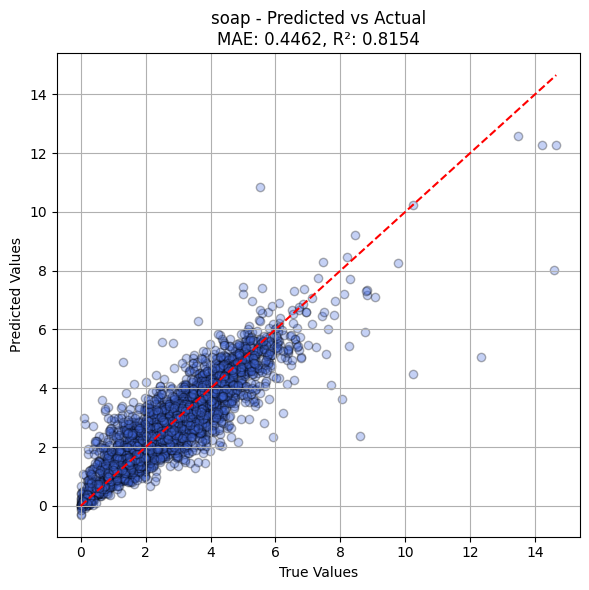

In [ ]:
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score
from tqdm import tqdm
import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV
import xgboost as xgb

descriptor_name = "soap"
X = X_soap

if True:
    print(f"\n🔍 Training with {descriptor_name}...\n")
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    # Ensure y is 1D
    y = np.ravel(y)

    # Split the data
    X_train, X_test, y_train, y_test = train_test_split(
        X_scaled, y, test_size=0.2, random_state=42
    )

    # Convert to DMatrix for XGBoost
    dtrain = xgb.DMatrix(X_train, label=y_train)
    dtest = xgb.DMatrix(X_test, label=y_test)

    # Set XGBoost parameters
    params = {
        "objective": "reg:squarederror",
        "eval_metric": "mae",
        "verbosity": 0,  # Silence default output
    }

    # Create evaluation watchlist
    watchlist = [(dtrain, "train"), (dtest, "eval")]

    # Custom training progress callback
    class TQDMCallback(xgb.callback.TrainingCallback):
        def __init__(self, total_rounds):
            self.pbar = tqdm(total=total_rounds, desc="Training Progress", unit="iter")

        def after_iteration(self, model, epoch, evals_log):
            self.pbar.update(1)
            return False

        def after_training(self, model):
            self.pbar.close()
            return model

    # Number of boosting rounds
    num_round = 100

    # Train model with TQDM progress (no duplicate logs)
    model = xgb.train(
        params=params,
        dtrain=dtrain,
        num_boost_round=num_round,
        evals=watchlist,
        callbacks=[TQDMCallback(num_round)],
        verbose_eval=False  # ✅ Suppress default metric logs
    )
    # Predict and evaluate
    y_pred = model.predict(dtest)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    accuracy = 1 - (mae / np.mean(y_test))  # Custom metric

    # Print evaluation results
    print(f"\n📊 {descriptor_name} Results:")
    print(f"Mean Absolute Error (MAE): {mae:.5f}")
    print(f"R² Score: {r2:.4f}")
    print(f"Custom Accuracy: {accuracy:.4f}")

    # Plot predicted vs actual
    plt.figure(figsize=(6, 6))
    plt.scatter(y_test, y_pred, alpha=0.3, color='royalblue', edgecolors='k')
    plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
    plt.xlabel("True Values")
    plt.ylabel("Predicted Values")
    plt.title(f"{descriptor_name} - Predicted vs Actual\nMAE: {mae:.4f}, R²: {r2:.4f}")
    plt.grid(True)
    plt.tight_layout()
    plt.show()



✅ Submission file saved as 'submission.csv'


In [7]:

#train_and_evaluate(X_cm, y, descriptor_name="Coulomb Matrix")


<h1>Testing

In [8]:
from ase import Atoms
from ase.data import atomic_numbers
from dscribe.descriptors import SOAP, CoulombMatrix
from tqdm import tqdm
import numpy as np
import os
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score
from xgboost import XGBRegressor
import pandas as pd

# Helper function to read xyz files
def read_xyz(file_path):
    with open(file_path, 'r') as f:
        lines = f.readlines()
        num_atoms = int(lines[0])
        atom_data = lines[2:2 + num_atoms]
        atoms = []
        coords = []
        for line in atom_data:
            parts = line.split()
            atoms.append(parts[0])
            coords.append([float(x) for x in parts[1:4]])
        return atoms, coords

# Load molecules
def load_molecules(path_template, count=5000):
    molecules = []
    for i in tqdm(range(1, count + 1), desc="Reading molecules"):
        path = path_template.format(i)
        atoms, coords = read_xyz(path)
        molecules.append(Atoms(symbols=atoms, positions=coords))
    return molecules

molecule = load_molecules("structures_test/mol_{}.xyz")


Reading molecules: 100%|██████████| 5000/5000 [00:00<00:00, 6152.37it/s]


In [13]:
X_test = compute_soap(molecule)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_test)

In [14]:

df = pd.read_csv("test.csv")
y = df["dipole_moment"].values
df.head(5)

,ID,dipole_moment
0,mol_1,NaN
1,mol_2,NaN
2,mol_3,NaN
3,mol_4,NaN
4,mol_5,NaN


In [16]:
dtest = xgb.DMatrix(X_scaled, label=X_test)

y_pred = model.predict(dtest)

In [18]:
submission = pd.DataFrame({
        "ID": [f"mol_{i+1}" for i in range(len(y_pred))],
        "dipole_moment": y_pred
    })
filename = f"submission.csv"
submission.to_csv(filename, index=False)
print(f"\n✅ Submission file saved as '{filename}'")


✅ Submission file saved as 'submission.csv'
